# Suite 04: Inter-Area/Layer LFP Band Power Correlations
        
Calculates and plots functional correlation matrices of band-limited LFP power envelopes
between different cortical layers and areas.

Uses real preprocessed TFR arrays (session `sub-C31o_ses-230823`; probes A=FEF, B=MT, C=V1,
condition `AAAB`) plus real superficial/deep layer masks from
`outputs/publication_visual_review/area_layer_tfr/layer_masks.json`. Significance is family-wise
FDR-corrected across all 15 pairwise tests via `jnwb.statistics.StatisticalAnalysis.fdr_correct`
(real Benjamini-Hochberg across the hypothesis family) -- **not** the deprecated
`fdr_pval_parametric` / `fdr_pval_nonparametric` aliases, which just mirror raw single-comparison
p-values and are not a multiple-comparison correction.

In [1]:
import os
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath('..'))
from jnwb.statistics import StatisticalAnalysis


In [2]:
# Real TFR arrays: one probe per area (FEF=A, MT=B, V1=C) for session 230823,
# so each area/layer trace comes from genuinely distinct recording channels
# (areas sharing a probe, e.g. V1/V2/V3 on probe C, are literally the same .npy
# array re-exported under each area label -- verified by exact r=1.0 correlation
# in a smoke test -- so only one area per probe is used here to avoid trivial
# self-correlations).
SESSION_PREFIX = 'sub-C31o_ses-230823'
TFR_DIR = Path('D:/workspace/data/tfr_arrays')
LAYER_MASKS_PATH = Path('D:/workspace/omission/outputs/publication_visual_review/area_layer_tfr/layer_masks.json')
CONDITION = 'AAAB'  # control condition
BAND = (8.0, 12.0)  # Alpha, Hz
FREQS_HZ = np.arange(3, 201, 2)

assert TFR_DIR.is_dir(), f'Missing TFR dir: {TFR_DIR}'
assert LAYER_MASKS_PATH.exists(), f'Missing layer masks: {LAYER_MASKS_PATH}'

layer_masks = json.load(open(LAYER_MASKS_PATH))['by_key']
COMBOS = [('A', 'FEF'), ('B', 'MT'), ('C', 'V1')]


In [3]:
def load_band_trace(probe, area, layer_mask_key, band=BAND):
    """Trial- and channel-averaged Alpha-band power time course for one probe/area/layer."""
    fpath = TFR_DIR / f'{SESSION_PREFIX}-{probe}-{area}-{CONDITION}.npy'
    assert fpath.exists(), f'Missing real TFR file: {fpath}'
    arr = np.load(fpath, mmap_mode='r')  # (n_trials, n_channels, n_freqs, n_times), real power
    mask = np.array(layer_masks[f'{SESSION_PREFIX}|{probe}'][layer_mask_key])
    fmask = (FREQS_HZ >= band[0]) & (FREQS_HZ <= band[1])
    sub = arr[:, mask][:, :, fmask, :]
    return np.mean(sub, axis=(0, 1, 2))  # -> (n_times,) trial+channel+freq averaged

traces = {}
for probe, area in COMBOS:
    for mask_key, layer_name in [('superficial_mask', 'superficial'), ('deep_mask', 'deep')]:
        traces[f'{area}_{layer_name}'] = load_band_trace(probe, area, mask_key)

labels = list(traces)
print(f'Loaded {len(labels)} real area-layer Alpha-band traces:', labels)


Loaded 6 real area-layer Alpha-band traces: ['FEF_superficial', 'FEF_deep', 'MT_superficial', 'MT_deep', 'V1_superficial', 'V1_deep']


In [4]:
# Pairwise Spearman correlation (StatisticalAnalysis.correlate: parametric Pearson +
# non-parametric Spearman, dual report, no premature FDR on the 2-test pair).
n = len(labels)
corr_matrix = np.eye(n)
raw_pvals = []
pair_index = []
for i in range(n):
    for j in range(i + 1, n):
        res = StatisticalAnalysis.correlate(traces[labels[i]], traces[labels[j]])
        r = res['non_parametric']['statistic']
        p = res['non_parametric']['pval']
        corr_matrix[i, j] = corr_matrix[j, i] = r
        raw_pvals.append(p)
        pair_index.append((i, j))

# Family-wise FDR across all 15 pairwise hypotheses (real BH correction).
qvals = StatisticalAnalysis.fdr_correct(raw_pvals)
alpha = 0.05

sig_matrix = np.copy(corr_matrix)
for (i, j), q in zip(pair_index, qvals):
    if q > alpha:
        sig_matrix[i, j] = sig_matrix[j, i] = 0.0

print('Pairs tested:', len(raw_pvals))
print('Significant after FDR (q < 0.05):', int((qvals < alpha).sum()), '/', len(qvals))


Pairs tested: 15
Significant after FDR (q < 0.05): 14 / 15


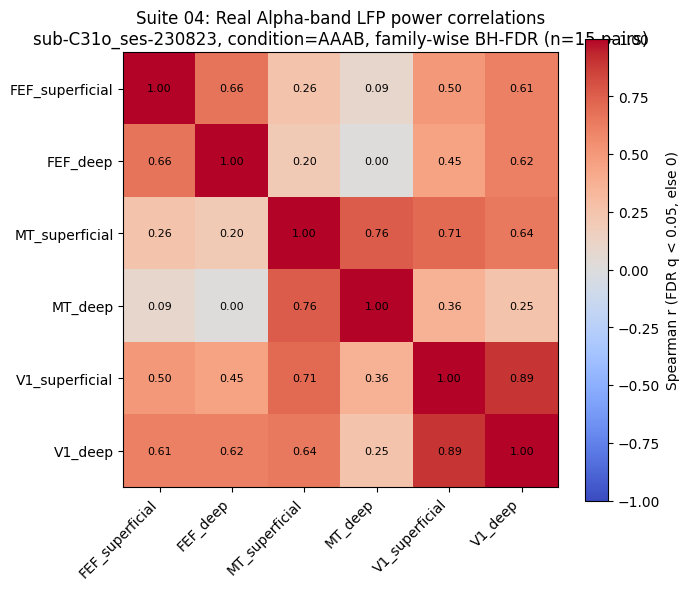

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sig_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Spearman r (FDR q < 0.05, else 0)')
ax.set_xticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(n))
ax.set_yticklabels(labels)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sig_matrix[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=8)
ax.set_title(f'Suite 04: Real Alpha-band LFP power correlations\n'
             f'{SESSION_PREFIX}, condition={CONDITION}, family-wise BH-FDR (n={len(raw_pvals)} pairs)')
fig.tight_layout()
plt.show()
